# Часть 1 — Анализ FastQC

Проведем FastQC анализ предложенных файлов (ниже представленно расположение на сервере) и объединим результаты с помощью MultiQC:
>/home/STUDY/FBMF/bioinformatics/rnaseq_map_star/raw_data/Eg_Treg_S71_R1_001.fastq.gz
/home/STUDY/FBMF/bioinformatics/rnaseq_map_star/raw_data/Eg_Treg_S71_R2_001.fastq.gz

Скрипт: [1_fastqc_raw.slurm](https://)

In [ ]:
#!/bin/bash
#SBATCH --job-name=fastqc_raw
#SBATCH --cpus-per-task=4
#SBATCH --mem=4gb
#SBATCH --time=00:30:00
#SBATCH --output=~/hw6/logs/fastqc_raw_%j.out
#SBATCH --partition=AMD9554-common

# Пути
DATA_DIR=~/hw6/data/raw
OUTPUT_DIR=~/hw6/results/fastqc_raw
MULTIQC_DIR=~/hw6/results/multiqc

mkdir -p $OUTPUT_DIR $MULTIQC_DIR

cd $DATA_DIR

echo "=== FastQC raw data ==="
fastqc -t 4 *.fastq.gz -o $OUTPUT_DIR

echo "=== MultiQC ==="
multiqc $OUTPUT_DIR -o $MULTIQC_DIR -n multiqc_raw_report

echo "=== Готово! ==="

Результаты MultiQC: [multiqc_raw_report.html](https://)

# Часть 2 — Тримминг

Из результатов отчета MultiQC оценим качество исходных данных:

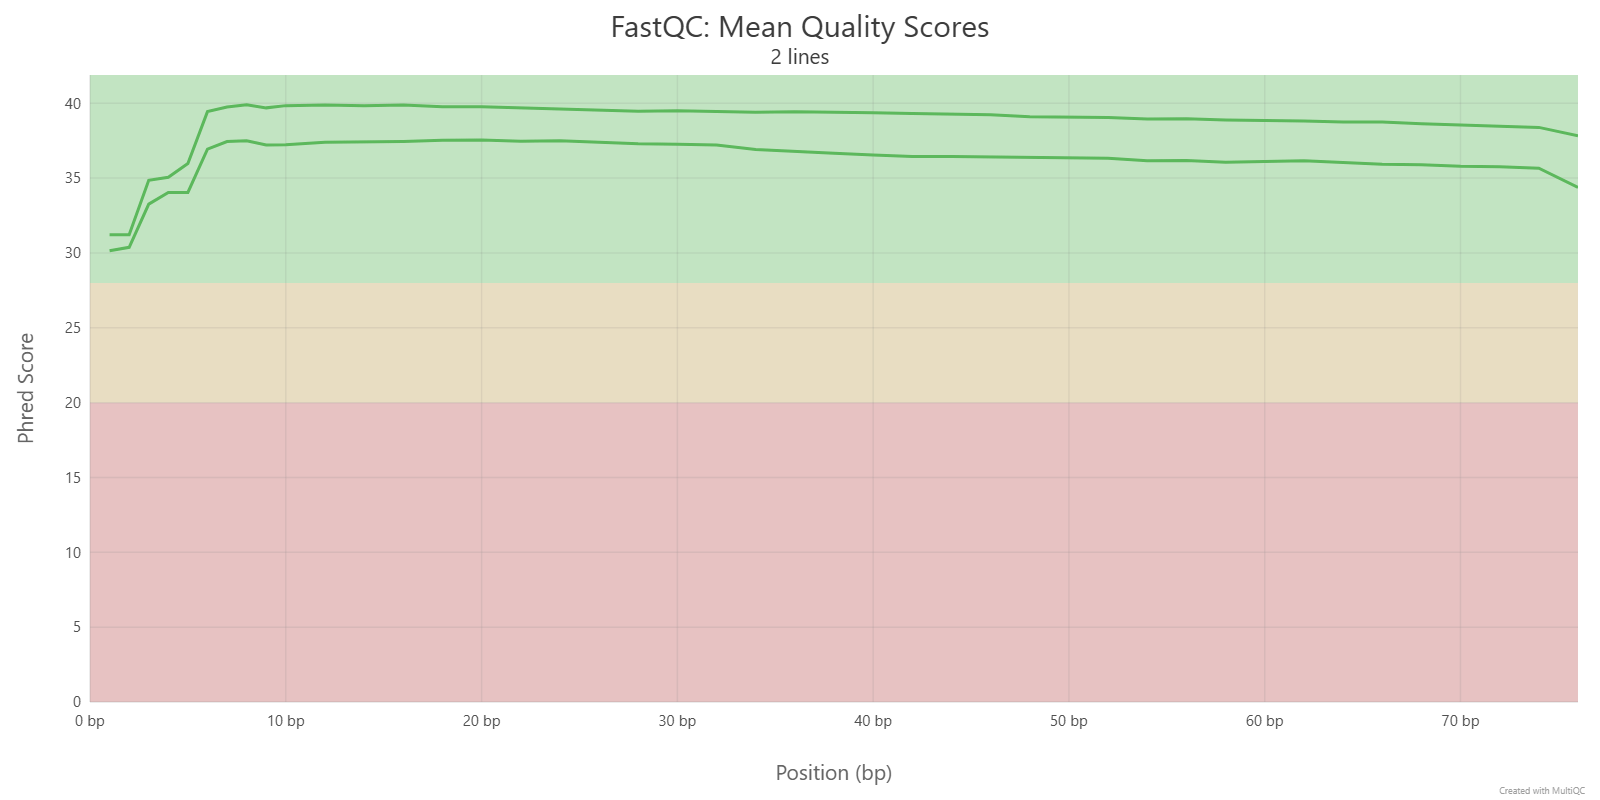

Риды полностью находятся в зеленой зоне, качество исходных данных высокое.

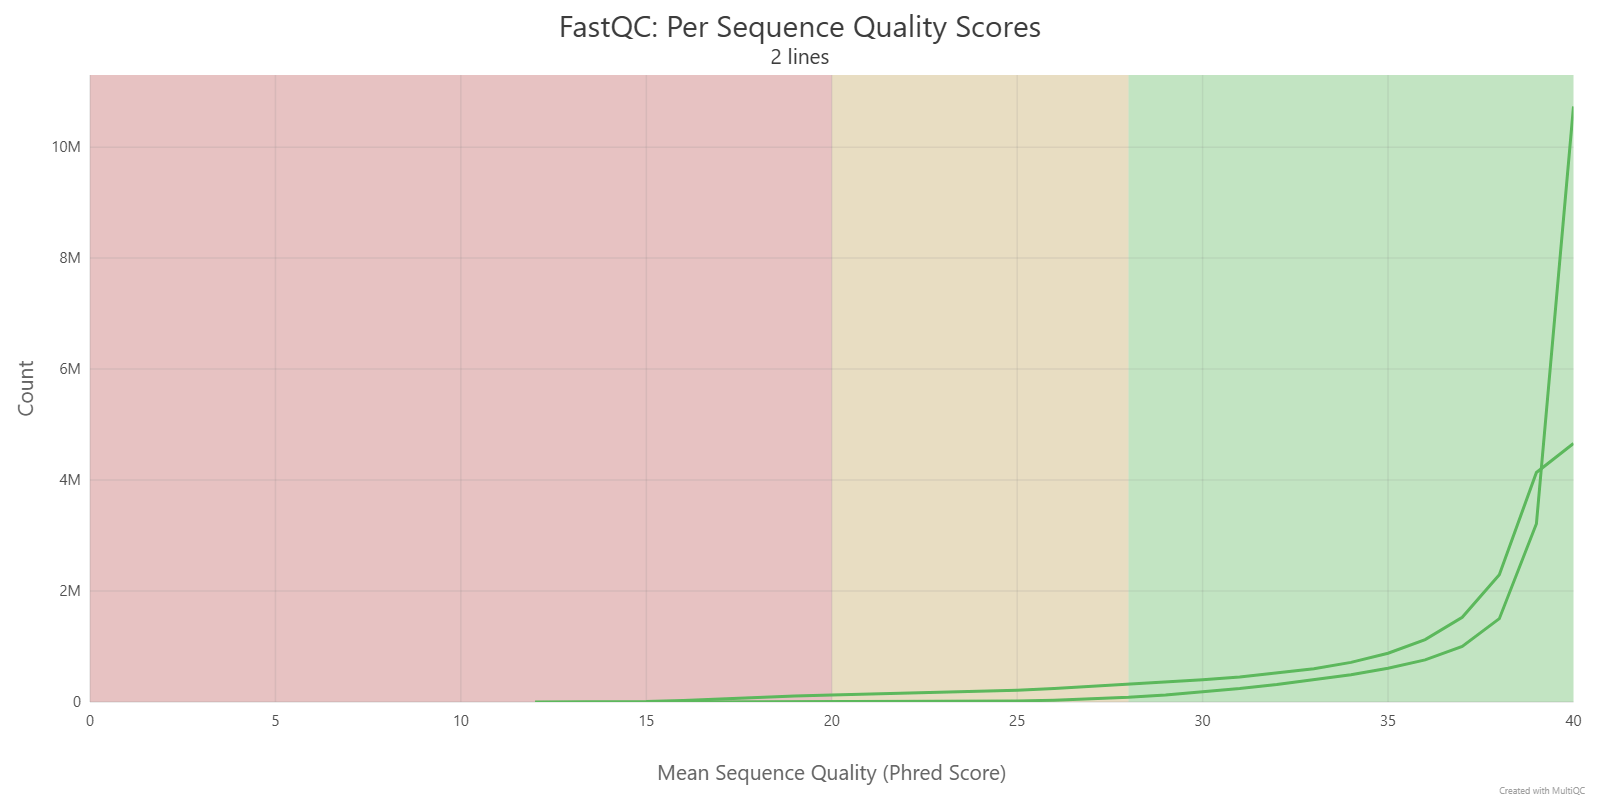

Наблюдается небольшое количество ридов с качеством 10-15 Phred.

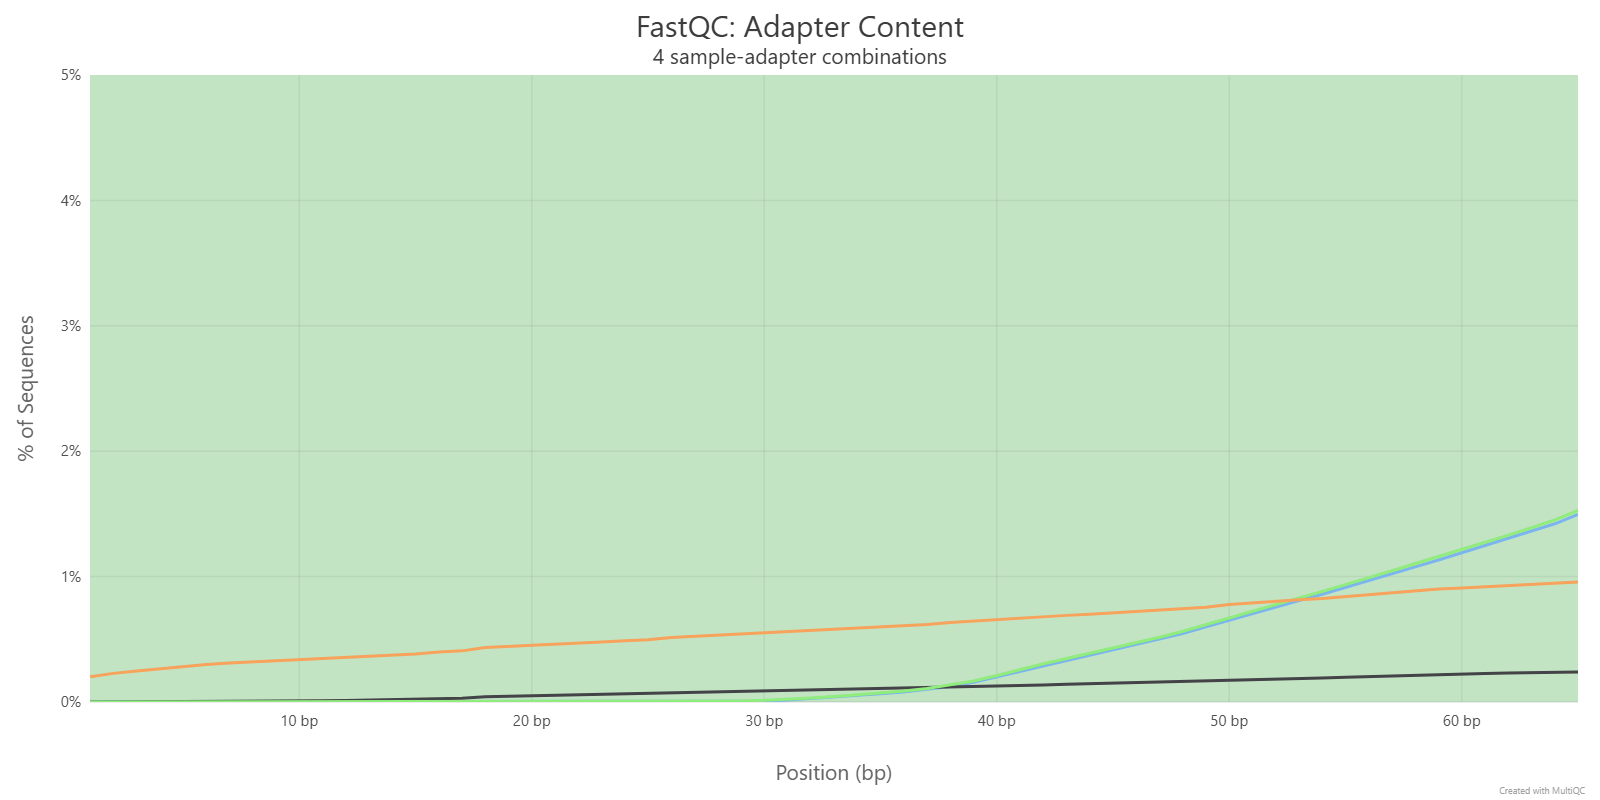

Адаптеры присутсвуют, каждый их представленных - менее 2% от последовательности.

Проведем тримминг данных с помощью fastp

Скрипт тримминга: [2_fastp.slurm](https://)

In [ ]:
#!/bin/bash
#SBATCH --job-name=fastp_trim
#SBATCH --cpus-per-task=4
#SBATCH --mem=4gb
#SBATCH --time=00:30:00
#SBATCH --output=~/hw6/logs/fastp_%j.out
#SBATCH --partition=AMD9554-common

RAW_DIR=~/hw6/data/raw
TRIMMED_DIR=~/hw6/data/trimmed
REPORT_DIR=~/hw6/results/multiqc

mkdir -p $TRIMMED_DIR $REPORT_DIR
cd $RAW_DIR

echo "=== Тримминг Eg_Treg_S71 ==="

fastp \
    -i Eg_Treg_S71_R1_001.fastq.gz \
    -I Eg_Treg_S71_R2_001.fastq.gz \
    -o $TRIMMED_DIR/Eg_Treg_S71_R1_trimmed.fastq.gz \
    -O $TRIMMED_DIR/Eg_Treg_S71_R2_trimmed.fastq.gz \
    --detect_adapter_for_pe \
    --cut_front --cut_tail \
    --cut_window_size 5 --cut_mean_quality 20 \
    --length_required 36 \
    --html $REPORT_DIR/Eg_Treg_S71_fastp.html

echo "=== Тримминг завершен ==="

Скрипт: [3_fastqc_trimmed.slurm](https://)

In [ ]:
#!/bin/bash
#SBATCH --job-name=fastqc_trimmed
#SBATCH --cpus-per-task=4
#SBATCH --mem=4gb
#SBATCH --time=00:30:00
#SBATCH --output=~/hw6/logs/fastqc_trimmed_%j.out
#SBATCH --partition=AMD9554-common

DATA_DIR=~/hw6/data/trimmed
OUTPUT_DIR=~/hw6/results/fastqc_trimmed
MULTIQC_DIR=~/hw6/results/multiqc

mkdir -p $OUTPUT_DIR $MULTIQC_DIR
cd $DATA_DIR

fastqc -t 4 *.fastq.gz -o $OUTPUT_DIR
multiqc $OUTPUT_DIR -o $MULTIQC_DIR -n multiqc_trimmed_report

echo "=== Готово! ==="

Результаты MultiQC: [multiqc_trimmed_report.html](https://)

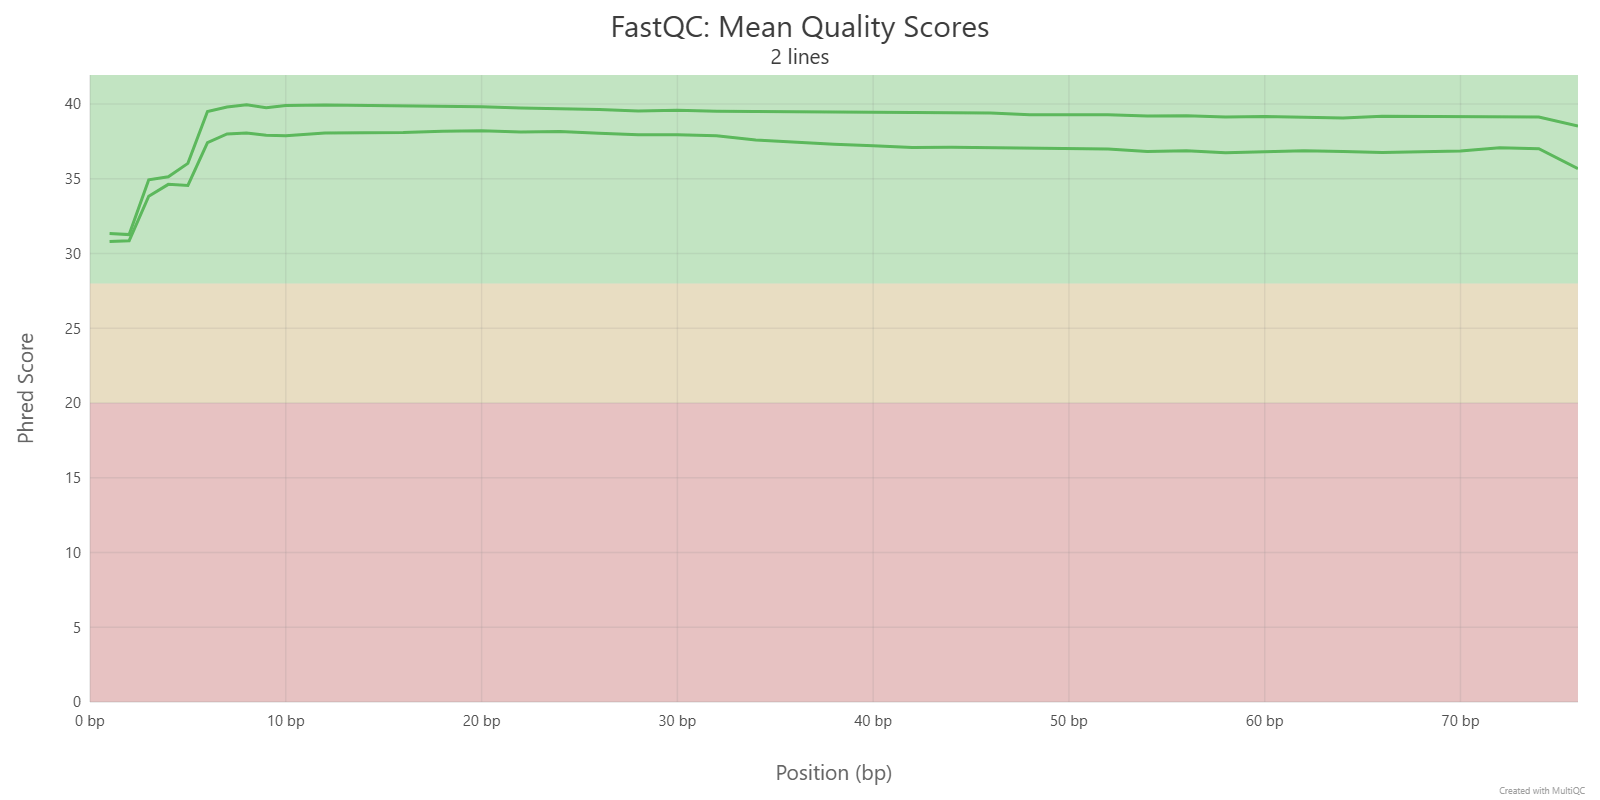

В результате тримминга показатели качества на концах ридов немного повысились (в результате применения "-- сut_front --cut_tail --cut_window_size 5 --cut_mean_quality 20")

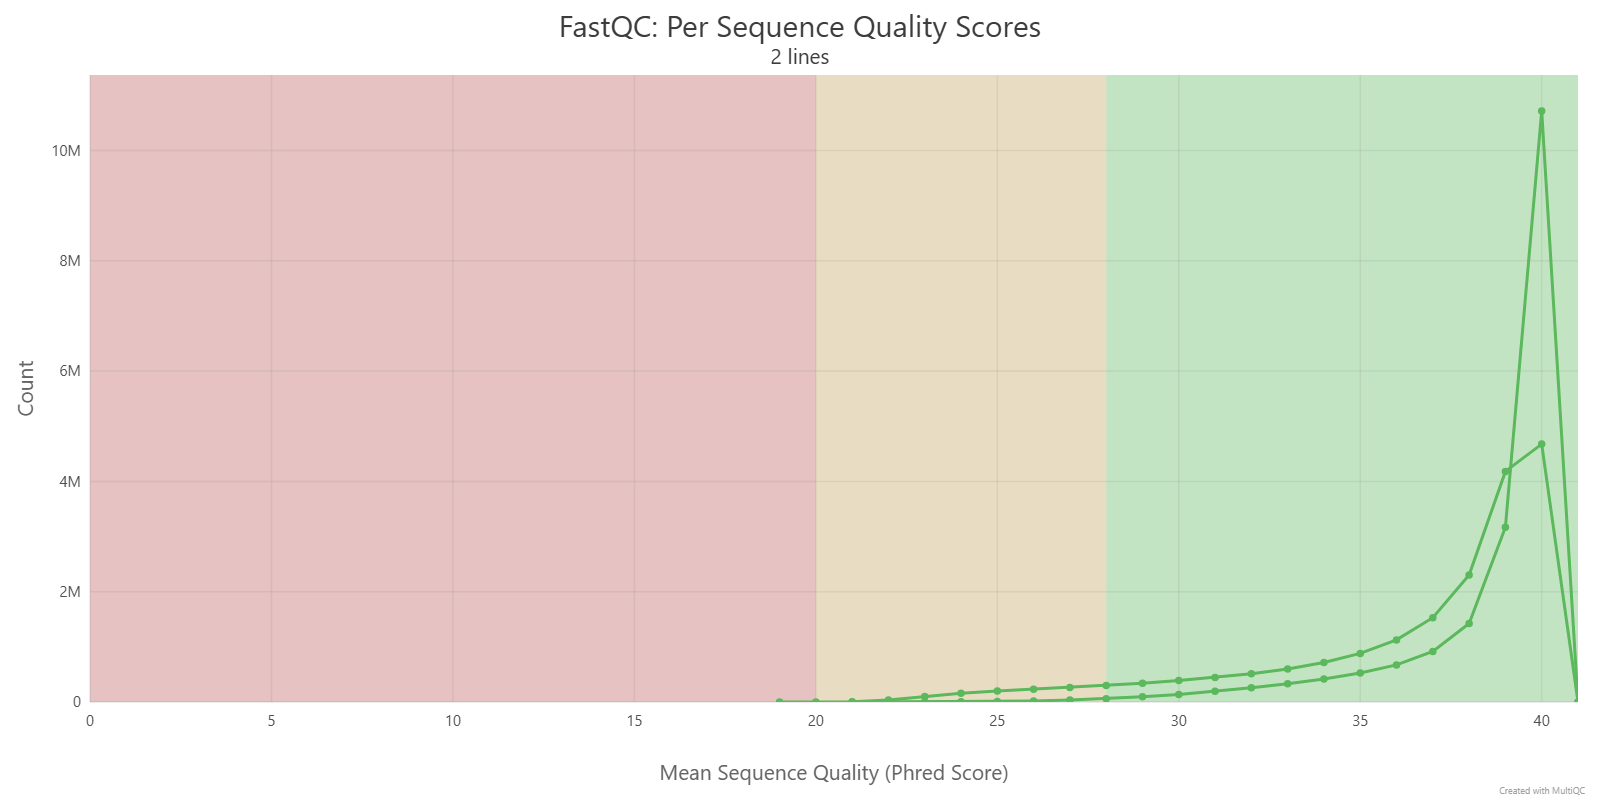

Низкокачественные риды отфильтрованы. Распределение стало чище. Теперь среднее качество ридов не опускается ниже примерно 19 Phred ( "--cut_window_size 5 --cut_mean_quality 20" )

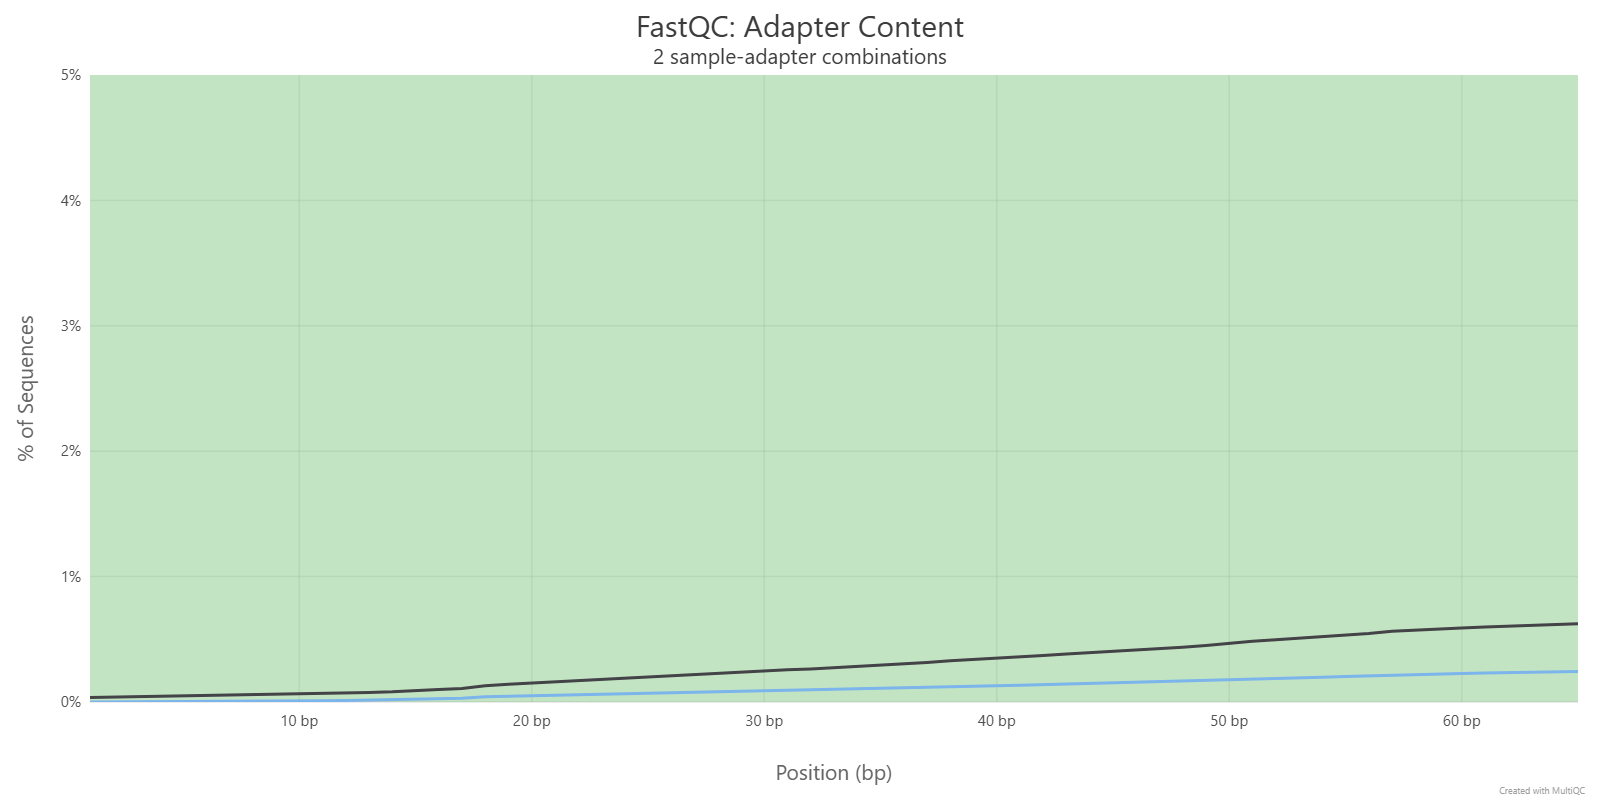

Содержание каждого из адаптеров снизилось до уровня ниже 1% от длины последовательности ридов.

Из результатов анализа [Eg_Treg_S71_fastp.html](https://):

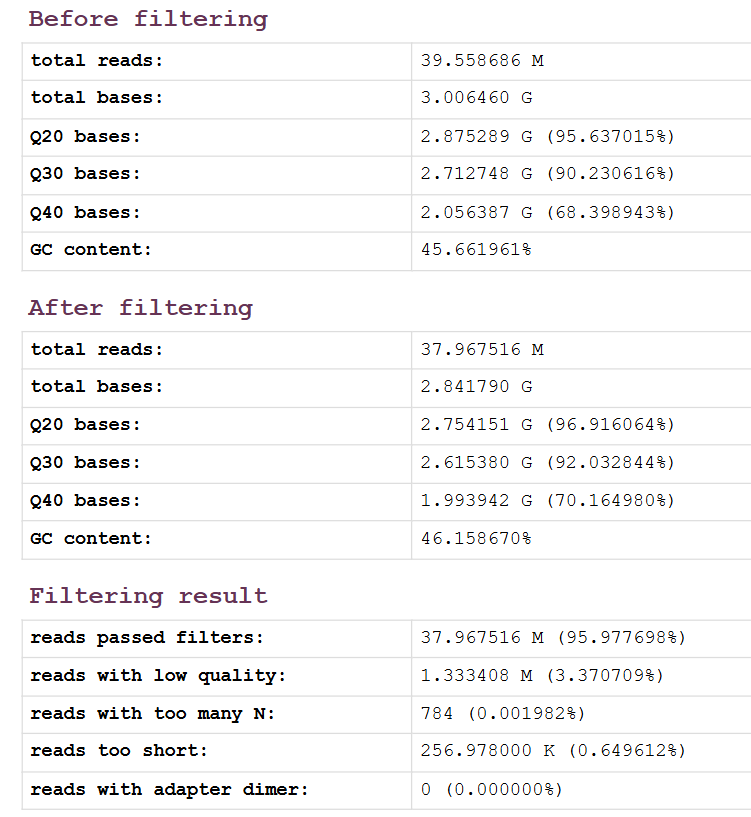

Для дальнейшего исследования будем использовать триммированные данные, т.к. их качество немного улучшено относительно исходного: Q30 вырос на 1.8% (снизился процент низкокачественных данных, сократилось содержание адаптеров). При этом потери ридов составили всего 4% (−1.59 M).

#Часть 3 — Выравнивание на референсный геном — STAR + StringTie

Проведем выравнивание ридов на референсный геном с помощью STAR.
> /home/STUDY/FBMF/bioinformatics/GRCh38/ - расположение референсного генома на сервере


Скрипт для выравнивания STAR: [4_star.slurm](https://)

In [ ]:
#!/bin/bash
#SBATCH --job-name=star_mapping
#SBATCH --cpus-per-task=34
#SBATCH --mem=128gb
#SBATCH --time=1:55:00
#SBATCH --output=~/hw6/logs/star_%j.out
#SBATCH --partition=AMD9554-common

export PATH="/home/STUDY/FBMF/bioinformatics/anaconda3/bin:$PATH"
ulimit -n 20000

GENOME_DIR="/home/STUDY/FBMF/bioinformatics/GRCh38/"
READS1=~/hw6/data/trimmed/Eg_Treg_S71_R1_trimmed.fastq.gz
READS2=~/hw6/data/trimmed/Eg_Treg_S71_R2_trimmed.fastq.gz
OUTPUT_DIR=~/hw6/results/star_alignment

mkdir -p $OUTPUT_DIR

STAR \
  --runThreadN 16 \
  --runMode alignReads \
  --genomeDir $GENOME_DIR \
  --readFilesIn $READS1 $READS2 \
  --readFilesCommand zcat \
  --outFileNamePrefix ${OUTPUT_DIR}/RNA_ \
  --outSAMtype BAM SortedByCoordinate \
  --quantMode GeneCounts

echo "Alignment Done"

В результате работы скрипта получены выровненные на референсный геном риды

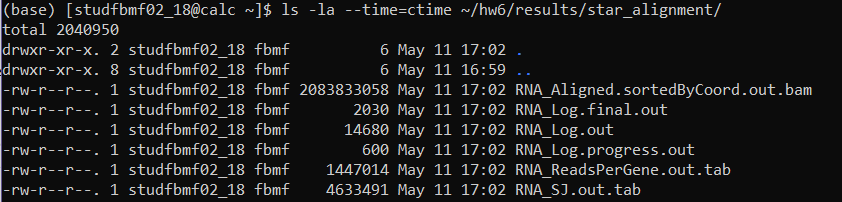

С помощью StringTie соберем транскрипты из выравненных ридов (BAM) и оценим их abundance.

Скрипт: [5_stringtie.slurm](https://)

In [ ]:
#!/bin/bash
#SBATCH --job-name=stringtie_assemble
#SBATCH --cpus-per-task=4
#SBATCH --mem=32gb
#SBATCH --time=1:00:00
#SBATCH --output=~/hw6/logs/stringtie_%j.out
#SBATCH --partition=AMD9554-common

export PATH="/home/STUDY/FBMF/bioinformatics/anaconda3/bin:$PATH"

BAM=~/hw6/results/star_alignment/RNA_Aligned.sortedByCoord.out.bam
OUTDIR=~/hw6/results/stringtie_out

mkdir -p $OUTDIR

stringtie $BAM \
    -o $OUTDIR/transcripts.gtf \
    -p $SLURM_CPUS_PER_TASK

echo "StringTie assembly completed"

В результате работы скрипта получен gtf-файл: [transcripts.gtf](https://)

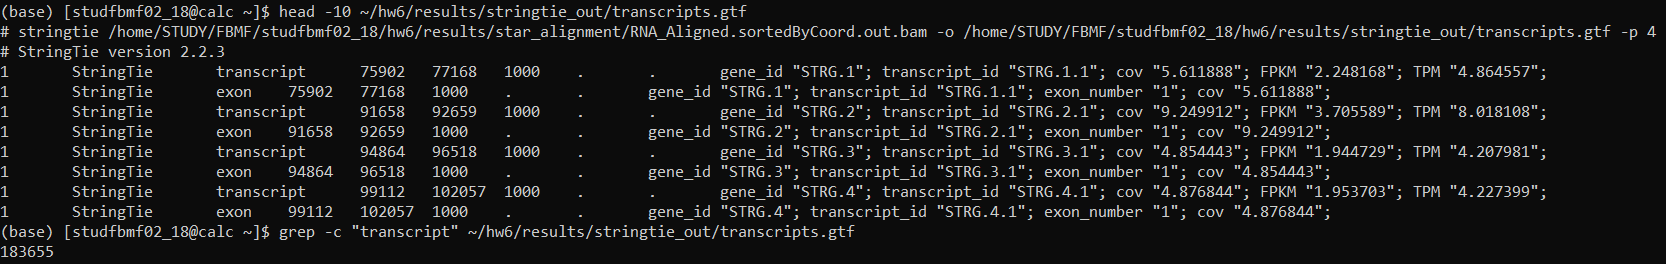

| № | Поле | Пример значения | Описание |
|---|------|----------------|----------|
| 1 | **chrom** | `1` | Идентификатора хромосомы/контига |
| 2 | **source** | `StringTie` | Метод |
| 3 | **type** | `transcript` или `exon` | Тип аннотируемой последовательности |
| 4 | **start** | `75902` | Начальная координата (1-based) |
| 5 | **end** | `77168` | Конечная координата |
| 6 | **score** | `1000` | Уровень достоверности |
| 7 | **strand** | `+`, `-`, или `.` | Цепь ДНК (прямая, обратная, неизвестно) |
| 8 | **frame** | `0`, `1`, `2`, `.` | Рамка считывания для CDS (для экзонов/транскриптов — `.`) |
| 9 | **attributes** | `gene_id "STRG.1"; transcript_id "STRG.1.1"; cov "5.61"; FPKM "2.25"; TPM "4.86"` | Дополнительная информация: идентификаторы гена/транскрипта, покрытие, FPKM, TPM |

Всего получено 183655 транскриптов.

**Что дает сборка транскриптов StringTie, для каких задач полезен transcripts.gtf?**

StringTie позволяет разобраться в структуре транскриптома (после выравнивания на референсном геноме): определяет типы аннотируемых фрагментов, находит их границы, оценивает уровень экспрессии каждого транскрипта (FPKM/TPM).

transcripts.gtf может быть полезен для выявления/анализа новых изоформ генов, исследования альтернативного сплайсинга, визуализации структуры транскриптомов.


# Часть 4 — Выравнивание на референсный геном —HTSeq

Теперь проведем выравнивание на референсный геном с помощью HTSeq.

Скрипт: [6_htseq.slurm](https://)

In [ ]:
#!/bin/bash
#SBATCH --job-name=htseq_count
#SBATCH --cpus-per-task=4
#SBATCH --mem=8gb
#SBATCH --time=0:30:00
#SBATCH --output=~/hw6/logs/htseq_%j.out
#SBATCH --partition=AMD9554-common

export PATH="/home/STUDY/FBMF/bioinformatics/anaconda3/bin:$PATH"

BAM=~/hw6/results/star_alignment/RNA_Aligned.sortedByCoord.out.bam
GTF=/home/STUDY/FBMF/bioinformatics/GRCh38/Homo_sapiens.GRCh38.110.chr.gtf
OUTDIR=~/hw6/results/htseq_out
mkdir -p $OUTDIR

htseq-count \
    --format bam \
    --order pos \
    --stranded no \
    --type exon \
    --idattr gene_id \
    $BAM $GTF > $OUTDIR/htseq_counts.txt

echo "HTSeq-count completed"

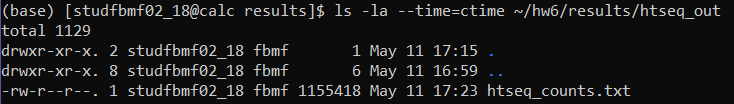

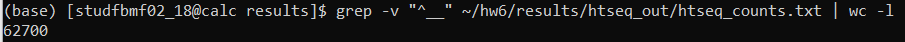

То есть получено 62700 уникальных генов в htseq_counts.txt.

# Сравнение каунтов STAR с HTSeq‑count

Pearson r = 0.7473, p-value = 0.00e+00


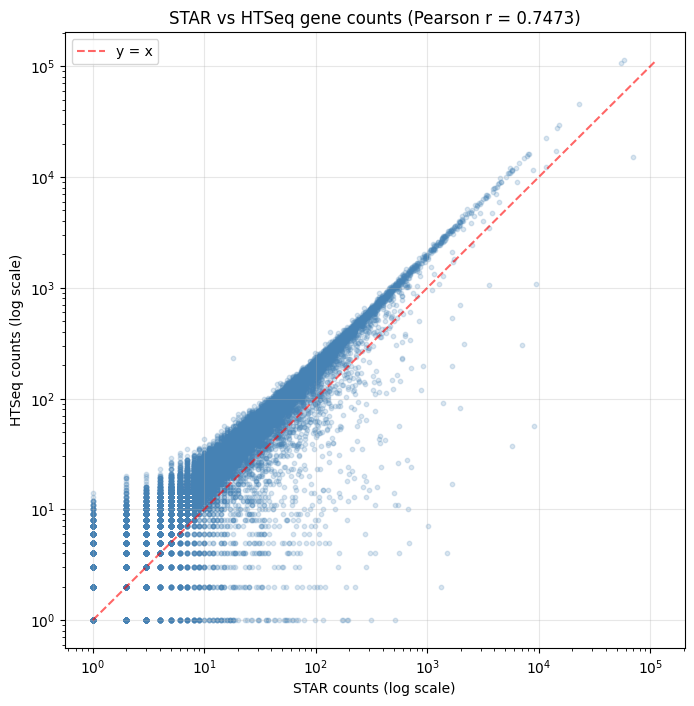

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

htseq = pd.read_csv('htseq_counts.txt', sep='\t', header=None, names=['gene_id', 'htseq_count'])
htseq = htseq[~htseq['gene_id'].str.startswith('__')]

star = pd.read_csv('RNA_ReadsPerGene.out.tab', sep='\t', header=None,
                   names=['gene_id', 'col2', 'star_count', 'col4', 'col5'])
star = star[~star['gene_id'].str.startswith('N_')]
star = star[~star['gene_id'].str.startswith('__')]

merged = pd.merge(htseq, star, on='gene_id', how='inner')
corr, p_val = pearsonr(merged['star_count'], merged['htseq_count'])
print(f"Pearson r = {corr:.4f}, p-value = {p_val:.2e}")

plt.figure(figsize=(8, 8))
plt.scatter(merged['star_count'], merged['htseq_count'], alpha=0.2, s=10, color='steelblue')
max_val = max(merged['star_count'].max(), merged['htseq_count'].max())
plt.plot([1, max_val], [1, max_val], 'r--', alpha=0.6, label='y = x')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('STAR counts (log scale)')
plt.ylabel('HTSeq counts (log scale)')
plt.title(f'STAR vs HTSeq gene counts (Pearson r = {corr:.4f})')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('star_vs_htseq.png', dpi=150)
plt.show()

Наблюдается высокая степень прямой корреляции в распределении каунтов для STAR и HTSeq выравниваний (r = 0.7473). Большая часть точек ориентирована в направлении прямой y = x. Ухудшение корреляции наблюдается при уменьшении каунтов, т.е. для наиболее низкоэкспрессируемых генов (выше чувствительность к шуму). Для генов с высоким уровнем экспрессии наблюдается высокая степень корреляции.

Различия в результатах двух методов могут возникать из-за разных алгоритмов исполнения. STAR производит подсчет каунтов в процессе выравнивания. HTSeq уже после выравнивания, учитывая особенности структуры данных. Это позволяет получить более актуальные результаты.

**Для дальнейшего DE‑анализа (DESeq2/edgeR)** лучше использовать каунты HTSeq, так как в этом случае результаты получены более гибкой настройкой алгоритма под конкретный транскриптом.